<a href="https://colab.research.google.com/github/saim9211/skin_classification/blob/main/skin_image_classification_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import zipfile
import shutil
import torch
import matplotlib.pyplot as plt

from google.colab import files
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [2]:
# Progress Bar
from tqdm import tqdm

# Visualization
import seaborn as sns

time to load the data

In [3]:
##device agnostic code
device="cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

## First i Upload the dataset in to my google drive then i download the dataset in to collab by this piece of script

In [4]:
# Install gdown for downloading from Google Drive
!pip install -qqq gdown

import os
import gdown

# Google Drive URL for the zip file
drive_url = "https://drive.google.com/file/d/1VwEw8HMu1XLQlCy2_2L5JrzaSmVDqqFO/view?usp=sharing"
# Define the local path where the zip file will be saved
local_zip_path = "/content/chest_xray.zip"

# Download the file using gdown
try:
    gdown.download(drive_url, local_zip_path, fuzzy=True)
    print(f"File downloaded to: {local_zip_path}")
    # Update zip_path to the local path for further operations
    zip_path = local_zip_path
    print("Local file exists after download:", os.path.exists(zip_path))
except Exception as e:
    print(f"Error downloading file: {e}")
    print("Please ensure the Google Drive link is correct and publicly accessible, or you might need to authenticate.")



Downloading...
From (original): https://drive.google.com/uc?id=1VwEw8HMu1XLQlCy2_2L5JrzaSmVDqqFO
From (redirected): https://drive.google.com/uc?id=1VwEw8HMu1XLQlCy2_2L5JrzaSmVDqqFO&confirm=t&uuid=6e68a3c4-c1cb-4c6c-b968-ac8462e56fd5
To: /content/chest_xray.zip
100%|██████████| 1.05G/1.05G [00:14<00:00, 73.5MB/s]

File downloaded to: /content/chest_xray.zip
Local file exists after download: True


In [5]:
import zipfile
import os

zip_path = "/content/chest_xray.zip"
extract_path = "/content/chest_xray"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully.")

Dataset extracted successfully.


In [6]:
print(os.listdir(extract_path))

['chest_xray']


In [7]:
dataset_dir = "/content/chest_xray/chest_xray"

In [8]:
dataset_dir

'/content/chest_xray/chest_xray'

In [9]:
train_dir = "/content/chest_xray/chest_xray/train"
test_dir = "/content/chest_xray/chest_xray/test"

# loading image

In [10]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [11]:
transform1 = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [12]:
from torchvision.datasets import ImageFolder
train_dataset=ImageFolder(train_dir,transform=transform1)
test_dataset=ImageFolder(test_dir,transform=transform1)

In [13]:
print("Train images:", len(train_dataset))
print("Test images:", len(test_dataset))
print("Classes:", train_dataset.classes)
print("Mapping:", train_dataset.class_to_idx)


Train images: 2698
Test images: 468
Classes: ['NORMAL', 'PNEUMONIA']
Mapping: {'NORMAL': 0, 'PNEUMONIA': 1}


In [14]:
from torch.utils.data import DataLoader
train_dataloader=DataLoader(train_dataset,
                            batch_size=32,
                            shuffle=True)
test_dataloader=DataLoader(test_dataset,
                           batch_size=32,
                           shuffle=True,
                    )


In [15]:
print(f"Train batches: {len(train_dataloader)} | Test batches: {len(test_dataloader)}")

Train batches: 85 | Test batches: 15


In [16]:
img,label=next(iter(train_dataloader))
print(img.shape)
print(label.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


# Eda Process

## check the data distribution

In [17]:
from collections import Counter

train_counts = Counter(train_dataset.targets)
test_counts = Counter(test_dataset.targets)

print("TRAIN DISTRIBUTION")
for idx, count in train_counts.items():
    print(train_dataset.classes[idx], ":", count)

print("\nTEST DISTRIBUTION")
for idx, count in test_counts.items():
    print(test_dataset.classes[idx], ":", count)

TRAIN DISTRIBUTION
NORMAL : 1349
PNEUMONIA : 1349

TEST DISTRIBUTION
NORMAL : 234
PNEUMONIA : 234


##visualize the data

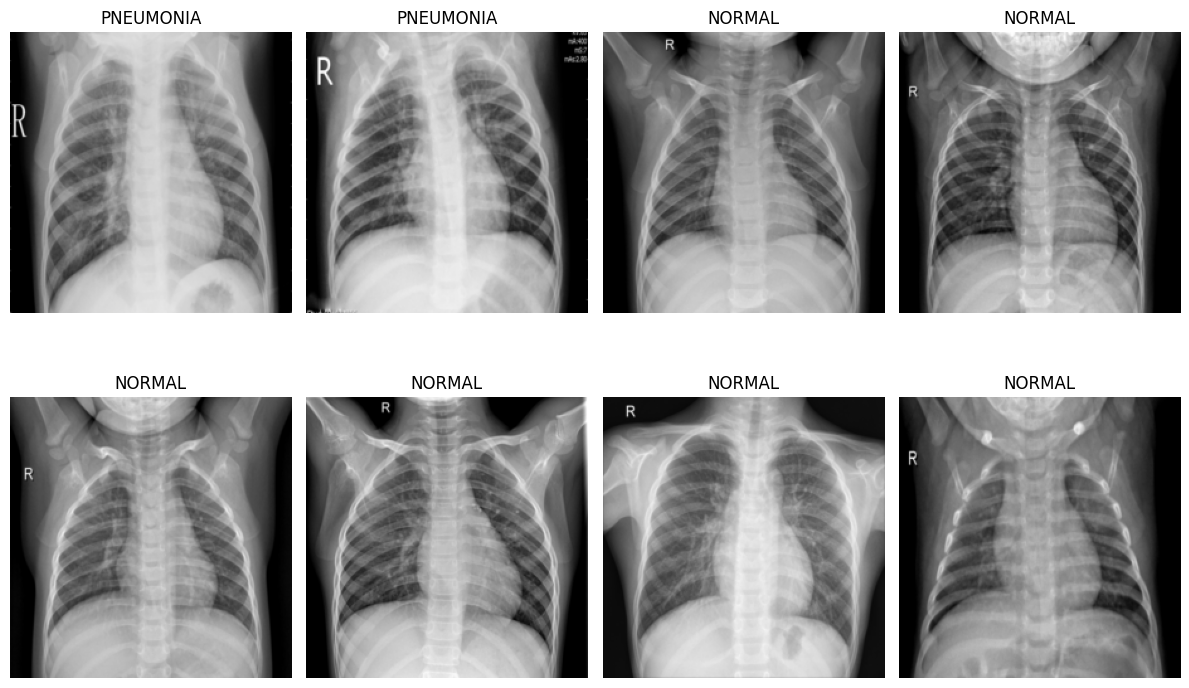

In [18]:
import matplotlib.pyplot as plt
import numpy as np

img, labels = next(iter(train_dataloader))

plt.figure(figsize=(12, 8))

for i in range(8):
    image = img[i].permute(1, 2, 0)

    # Undo normalization
    mean = torch.tensor([0.485, 0.456, 0.406])
    std = torch.tensor([0.229, 0.224, 0.225])

    image = image * std + mean
    image = image.clamp(0, 1)

    plt.subplot(2, 4, i + 1)
    plt.imshow(image)
    plt.title(train_dataset.classes[labels[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

## checking the size of the images

In [19]:
from PIL import Image
import os

sample_count = 5

for i, (path, label) in enumerate(train_dataset.samples[:sample_count]):

    try:
        img = Image.open(path)

        print(
            f"{i+1}. "
            f"{os.path.basename(path)} | "
            f"Size: {img.size} | "
            f"Mode: {img.mode} | "
            f"Class: {train_dataset.classes[label]}"
        )

    except Exception as e:
        print("ERROR:", path, e)

1. NORMAL-1003233-0001.jpeg | Size: (2572, 2476) | Mode: L | Class: NORMAL
2. NORMAL-1012843-0001.jpeg | Size: (1982, 1751) | Mode: L | Class: NORMAL
3. NORMAL-1014768-0001.jpeg | Size: (1236, 1013) | Mode: L | Class: NORMAL
4. NORMAL-1023731-0001.jpeg | Size: (1414, 1206) | Mode: L | Class: NORMAL
5. NORMAL-1029510-0001.jpeg | Size: (1786, 1449) | Mode: L | Class: NORMAL


In [20]:
from PIL import Image
import os

# Process at least 15 images from the training dataset
num_images_to_process = 15

for i, (image_path, label) in enumerate(train_dataset.samples[:num_images_to_process]):
    try:
        # Open the image using PIL
        pil_image = Image.open(image_path)

        # Apply the defined transforms
        transformed_image = transform1(pil_image)

        # Print the shape of the transformed image
        print(f"--- Image {i+1} ---")
        print(f"  File: {os.path.basename(image_path)}")
        print(f"  Original image path: {image_path}")
        print(f"  Shape after transformations: {transformed_image.shape}")
        print(f"  Predicted Label: {train_dataset.classes[label]}")

    except Exception as e:
        print(f"Error processing image {os.path.basename(image_path)}: {e}")


--- Image 1 ---
  File: NORMAL-1003233-0001.jpeg
  Original image path: /content/chest_xray/chest_xray/train/NORMAL/NORMAL-1003233-0001.jpeg
  Shape after transformations: torch.Size([3, 224, 224])
  Predicted Label: NORMAL
--- Image 2 ---
  File: NORMAL-1012843-0001.jpeg
  Original image path: /content/chest_xray/chest_xray/train/NORMAL/NORMAL-1012843-0001.jpeg
  Shape after transformations: torch.Size([3, 224, 224])
  Predicted Label: NORMAL
--- Image 3 ---
  File: NORMAL-1014768-0001.jpeg
  Original image path: /content/chest_xray/chest_xray/train/NORMAL/NORMAL-1014768-0001.jpeg
  Shape after transformations: torch.Size([3, 224, 224])
  Predicted Label: NORMAL
--- Image 4 ---
  File: NORMAL-1023731-0001.jpeg
  Original image path: /content/chest_xray/chest_xray/train/NORMAL/NORMAL-1023731-0001.jpeg
  Shape after transformations: torch.Size([3, 224, 224])
  Predicted Label: NORMAL
--- Image 5 ---
  File: NORMAL-1029510-0001.jpeg
  Original image path: /content/chest_xray/chest_xray/t

## checking the corrupted file

In [21]:
from PIL import Image

def check_corrupted(dataset):

    corrupted = []

    for path, label in dataset.samples:

        try:
            img = Image.open(path)
            img.verify()

        except Exception:
            corrupted.append(path)

    return corrupted


train_corrupted = check_corrupted(train_dataset)
test_corrupted = check_corrupted(test_dataset)

print("Corrupted train images:", len(train_corrupted))
print("Corrupted test images:", len(test_corrupted))

Corrupted train images: 0
Corrupted test images: 0


# dividing the data in to train/val/test split  train 80% -> train 60 and 20 val and remaining 20 to test

In [22]:
from torch.utils.data import random_split, DataLoader

# As per user request ("only test, train data"),
# the entire `train_dataset` will be used for training,
# and no separate validation set will be created from it in this step.

# # Original validation split logic (commented out):
# train_size = int(0.8 * len(train_dataset))
# val_size = len(train_dataset) - train_size
#
# train_subset, val_subset = random_split(
#     train_dataset,
#     [train_size, val_size],
#     generator=torch.Generator().manual_seed(42)
# )

print("Training images:", len(train_dataset)) # Now refers to the full train_dataset
# print("Validation images:", len(val_subset)) # Removed as no validation split is performed
print("Test images:", len(test_dataset))


Training images: 2698
Test images: 468


## dataloader for it

In [23]:
train_loader = DataLoader(
    train_dataset, # Changed from train_subset to train_dataset
    batch_size=32,
    shuffle=True
)

# Removed val_loader as there is no separate validation set now
# val_loader = DataLoader(
#     val_subset,
#     batch_size=32,
#     shuffle=False
# )

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False

)


##class imbalance check

In [24]:
import torch
from collections import Counter

train_labels = [
    # Directly use train_dataset.targets as no subset is created anymore
    train_dataset.targets[i] for i in range(len(train_dataset))
]

class_counts = Counter(train_labels)

print("Training class distribution:")

for class_id, count in class_counts.items():
    print(
        train_dataset.classes[class_id],
        ":",
        count
    )


Training class distribution:
NORMAL : 1349
PNEUMONIA : 1349


In [25]:
num_classes = len(train_dataset.classes)
total_samples = len(train_labels)

class_weights = []

for class_id in range(num_classes):

    count = class_counts[class_id]

    weight = total_samples / (
        num_classes * count
    )

    class_weights.append(weight)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
)

print("Class weights:", class_weights)

Class weights: tensor([1., 1.])


# training and testing model

In [26]:
import  torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
import torchvision

single model class

In [27]:
weights=torchvision.models.EfficientNet_B0_Weights.DEFAULT
model=torchvision.models.efficientnet_b0(weights=weights)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 71.1MB/s]


In [28]:
!pip install torchinfo

In [29]:
# Print a summary using torchinfo (uncomment for actual output)
from torchinfo import summary
summary(model=model,
        input_size=(32, 3, 224, 224), # make sure this is "input_size", not "input_shape"
        # col_names=["input_size"], # uncomment for smaller output
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
)

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [32, 3, 224, 224]    [32, 1000]           --                   True
├─Sequential (features)                                      [32, 3, 224, 224]    [32, 1280, 7, 7]     --                   True
│    └─Conv2dNormActivation (0)                              [32, 3, 224, 224]    [32, 32, 112, 112]   --                   True
│    │    └─Conv2d (0)                                       [32, 3, 224, 224]    [32, 32, 112, 112]   864                  True
│    │    └─BatchNorm2d (1)                                  [32, 32, 112, 112]   [32, 32, 112, 112]   64                   True
│    │    └─SiLU (2)                                         [32, 32, 112, 112]   [32, 32, 112, 112]   --                   --
│    └─Sequential (1)                                        [32, 32, 112, 112]   [32, 16, 112

for the multimodel  we create the create_model function

In [84]:
import torch.nn as nn

torch.manual_seed(42)
torch.cuda.manual_seed(42)
out_dt = len(class_counts)

# Access the original model within the OptimizedModule if it exists, otherwise use model directly.
# This ensures we modify the actual underlying model, not the compiled wrapper.
# If model was already compiled, model._orig_mod is the actual EfficientNet_B0 instance.
# If not, model itself is the EfficientNet_B0 instance.
current_model_instance = model._orig_mod if hasattr(model, '_orig_mod') else model

# Freeze all base layers by setting requires_grad attribute to False.
# Iterate over the parameters of the 'features' part of the *original* model.
for param in current_model_instance.features.parameters():
    param.requires_grad = False

# Update the classifier head to suit our problem.
# For EfficientNet_B0, the classifier is a Sequential module at `model.classifier`.
model.classifier = torch.nn.Sequential(
    nn.Dropout(p=0.5, inplace=True),
    nn.Linear(in_features=1280,  # EfficientNet_B0's last feature layer output size
              out_features=out_dt, # Use the dynamically determined number of output classes
              bias=True).to(device)
)

# Move the newly created classifier (part of current_model_instance) to the device.
model.classifier



Sequential(
  (0): Dropout(p=0.5, inplace=True)
  (1): Linear(in_features=1280, out_features=2, bias=True)
)

In [76]:
# # Do a summary *after* freezing the features and changing the output classifier layer (uncomment for actual output)
summary(model,
        input_size=(32, 3, 224, 224), # make sure this is "input_size", not "input_shape" (batch_size, color_channels, height, width)
        verbose=0,
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
)

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [32, 3, 224, 224]    [32, 2]              --                   Partial
├─Sequential (features)                                      [32, 3, 224, 224]    [32, 1280, 7, 7]     --                   False
│    └─Conv2dNormActivation (0)                              [32, 3, 224, 224]    [32, 32, 112, 112]   --                   False
│    │    └─Conv2d (0)                                       [32, 3, 224, 224]    [32, 32, 112, 112]   (864)                False
│    │    └─BatchNorm2d (1)                                  [32, 32, 112, 112]   [32, 32, 112, 112]   (64)                 False
│    │    └─SiLU (2)                                         [32, 32, 112, 112]   [32, 32, 112, 112]   --                   --
│    └─Sequential (1)                                        [32, 32, 112, 112]   [32, 

## multimodel class

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

def create_model(model_name, num_classes, device):

    if model_name == "efficientnet_b0":
        model = models.efficientnet_b0(
            weights=models.EfficientNet_B0_Weights.DEFAULT
        )

        # Freeze all features first
        for param in model.features.parameters():
            param.requires_grad = False

        # Unfreeze last block (typo fixed here)
        for param in model.features[-1:].parameters():
            param.requires_grad = True

        # --- UPDATED CLASSIFIER TO MATCH OTHERS ---
        # EfficientNet's input feature size is 1280
        model.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(model.classifier[1].in_features, 512), # First linear layer reduces to 512
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),                                 # Extra dropout for stability
            nn.Linear(512, num_classes)                      # Final output layer
        )

    elif model_name == "resnet18":
        model = models.resnet18(
            weights=models.ResNet18_Weights.DEFAULT
        )

        # Freeze everything
        for param in model.parameters():
            param.requires_grad = False

        # Unfreeze layer4
        for param in model.layer4.parameters():
            param.requires_grad = True

        # This was already good and consistent
        model.fc = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(model.fc.in_features, 256), # ResNet's input feature size is 512
            nn.ReLU(inplace=True),
            nn.Linear(256, num_classes)
        )

    elif model_name == "densenet121":
        model = models.densenet121(
            weights=models.DenseNet121_Weights.DEFAULT
        )

        # Freeze all
        for param in model.features.parameters():
            param.requires_grad = False

        # Unfreeze final dense block
        for param in model.features.denseblock4.parameters():
            param.requires_grad = True

        # This was already good and consistent
        model.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(model.classifier.in_features, 512), # DenseNet's input feature size is 1024
            nn.ReLU(inplace=True),
            nn.Linear(512, num_classes)
        )

    else:
        raise ValueError(
            "Choose from: efficientnet_b0, resnet18, densenet121"
        )

    model = model.to(device)

    return model

In [ ]:
efficientnet = create_model("efficientnet_b0", num_classes=2, device=device)

resnet = create_model("resnet18", num_classes=2, device=device)

densenet = create_model("densenet121", num_classes=2, device=device)

In [ ]:
resnet

In [75]:
# Print a summary using torchinfo (uncomment for actual output)
from torchinfo import summary
summary(model=resnet,
        input_size=(32, 3, 224, 224), # make sure this is "input_size", not "input_shape"
        # col_names=["input_size"], # uncomment for smaller output
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
)

Layer (type (var_name))                  Input Shape          Output Shape         Param #              Trainable
ResNet (ResNet)                          [32, 3, 224, 224]    [32, 2]              --                   Partial
├─Conv2d (conv1)                         [32, 3, 224, 224]    [32, 64, 112, 112]   (9,408)              False
├─BatchNorm2d (bn1)                      [32, 64, 112, 112]   [32, 64, 112, 112]   (128)                False
├─ReLU (relu)                            [32, 64, 112, 112]   [32, 64, 112, 112]   --                   --
├─MaxPool2d (maxpool)                    [32, 64, 112, 112]   [32, 64, 56, 56]     --                   --
├─Sequential (layer1)                    [32, 64, 56, 56]     [32, 64, 56, 56]     --                   False
│    └─BasicBlock (0)                    [32, 64, 56, 56]     [32, 64, 56, 56]     --                   False
│    │    └─Conv2d (conv1)               [32, 64, 56, 56]     [32, 64, 56, 56]     (36,864)             False
│    │    

## creating the training step function

In [74]:
from tqdm.auto import tqdm
def train_step(model, dataloader, loss_fn, optimizer, device):
  train_loss, train_acc = 0, 0
  train_total = 0 # Initialize train_total

  for X,y in tqdm(dataloader):
    X,Y=X.to(device),y.to(device)

    y_pred=model(X)

    loss=loss_fn(y_pred,Y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()


    train_loss+=loss.item()

    # Calculate predictions
    predicted = torch.argmax(y_pred, dim=1)

    # Calculate correct predictions
    train_acc += (predicted == Y).sum().item()

    train_total += Y.size(0)


  train_loss=train_loss/len(dataloader)
  train_acc=train_acc/ train_total
  return train_loss,train_acc

In [73]:
from tqdm.auto import tqdm
def test_Step(
    model,
    dataloader,
    loss_fn,
    device,):
  model.eval()
  test_loss,test_acc=0,0
  test_total = 0 # Initialize test_total
  test_correct = 0 # Initialize test_correct

   # No gradient calculation
  with torch.inference_mode():
    for X,y in tqdm(dataloader):
      X,y=X.to(device),y.to(device)

      pred=model(X)
      loss=loss_fn(pred,y)
      test_loss+=loss.item()

      # Calculate predictions
      predicted = torch.argmax(pred, dim=1)

      # Calculate correct predictions
      test_correct += (predicted == y).sum().item() # Accumulate correct predictions

      test_total += y.size(0)

    # Average loss
    test_loss = test_loss / len(dataloader)

    # Accuracy
    test_acc = test_correct / test_total

    return test_loss, test_acc

In [85]:
# Class 0 = NORMAL, Class 1 = PNEUMONIA
# Since the data is balanced (234 vs 234), we don't need extreme weights.
# We will give a slight nudge (1.2) to the NORMAL class to stop the model from over-predicting Pneumonia.
class_weights = torch.tensor([1.2, 1.0]).to(device)

loss_fn = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

In [69]:
def train(model,train_dataloader,test_dataloader,optimizer,loss_fn,epochs,device):
  result= {
  "train_loss":[],
  "train_acc":[],
  "test_loss":[],
  "test_acc":[]
  }
  for epoch in tqdm(range(epochs)):
    train_loss,train_acc=train_step(model=model,
                                  dataloader=train_dataloader,
                                  loss_fn=loss_fn,
                                  optimizer=optimizer,
                                  device=device)
    test_loss,test_acc=test_Step(model=model,
                            dataloader=test_dataloader,
                            loss_fn=loss_fn,
                            device=device)

    result["train_loss"].append(train_loss)
    result["train_acc"].append(train_acc)
    result["test_loss"].append(test_loss)
    result["test_acc"].append(test_acc)

     # Print results
    print(
            f"Epoch: {epoch + 1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.2%} | "
            f"Test Loss: {test_loss:.4f} | "
            f"Test Acc: {test_acc:.2%}"
        )
  return result

In [70]:
import matplotlib.pyplot as plt

def plot_loss_curves(train_loss, val_loss, train_acc=None, val_acc=None, save_path=None):
    """
    Plot training and validation loss (and optionally accuracy) curves.

    Args:
        train_losses (list): Training loss per epoch
        val_losses (list): Validation loss per epoch
        train_accs (list, optional): Training accuracy per epoch
        val_accs (list, optional): Validation accuracy per epoch
        save_path (str, optional): Path to save the figure
    """
    epochs = range(1, len(train_loss) + 1)

    if train_acc is not None and val_acc is not None:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    else:
        fig, axes = plt.subplots(1, 1, figsize=(7, 5))
        axes = [axes]

    # --- Loss curve ---
    axes[0].plot(epochs, train_loss, 'b-o', label='Train Loss', linewidth=2)
    axes[0].plot(epochs, val_loss, 'r-o', label='Val Loss', linewidth=2)
    axes[0].set_title('Loss Curve', fontsize=14)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # --- Accuracy curve (optional) ---
    if train_acc is not None and val_acc is not None:
        axes[1].plot(epochs, train_acc, 'b-o', label='Train Acc', linewidth=2)
        axes[1].plot(epochs, val_acc, 'r-o', label='Val Acc', linewidth=2)
        axes[1].set_title('Accuracy Curve', fontsize=14)
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Accuracy')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved plot to {save_path}")
    plt.show()

In [71]:
# Before training
print("Trainable params:", sum(p.requires_grad for p in model.parameters()))
print("Learning rate:", optimizer.param_groups[0]['lr'])



Trainable params: 2
Learning rate: 0.0001


In [86]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Ensure the specific model being trained is on the correct device.
# Although create_model should handle this, an explicit call here acts as a safeguard
# especially if components were added/modified after initial creation.
efficientnet = efficientnet.to(device)

# Initialize the optimizer for the *specific* model being trained.
# This ensures the optimizer's state (e.g., momentum buffers) is also on the correct device
# and it's optimizing the parameters of 'efficientnet'.

result=train(
    model=model,
    train_dataloader=train_loader,
    test_dataloader=test_loader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=5,
    device=device
)

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/85 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

Epoch: 1/5 | Train Loss: 0.6122 | Train Acc: 65.68% | Test Loss: 0.5787 | Test Acc: 73.29%


  0%|          | 0/85 [00:00<?, ?it/s]

...

  0%|          | 0/15 [00:00<?, ?it/s]

Epoch: 4/5 | Train Loss: 0.3419 | Train Acc: 91.51% | Test Loss: 0.4029 | Test Acc: 84.19%


  0%|          | 0/85 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

Epoch: 5/5 | Train Loss: 0.3059 | Train Acc: 92.25% | Test Loss: 0.3792 | Test Acc: 83.55%


In [87]:
!pip install -qqq torchmetrics

import torch
import torchmetrics.functional as tm

# Set model to evaluation mode
model.eval()

all_preds = []
all_labels = []

with torch.inference_mode():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        predictions = torch.argmax(outputs, dim=1)

        all_preds.append(predictions)
        all_labels.append(labels)

# Concatenate all predictions and labels
all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)

# Calculate metrics
# Ensure num_classes is passed to the metrics functions
precision = tm.precision(all_preds, all_labels, task="binary", num_classes=num_classes)
recall = tm.recall(all_preds, all_labels, task="binary", num_classes=num_classes)
f1_score = tm.f1_score(all_preds, all_labels, task="binary", num_classes=num_classes)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1_score:.4f}")

Precision: 0.7814
Recall: 0.9316
F1-Score: 0.8499


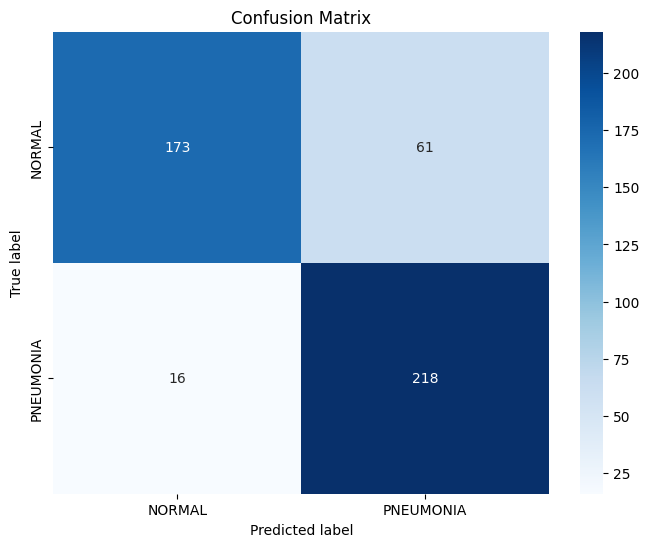

In [88]:
import torchmetrics.functional as tm
import seaborn as sns
import matplotlib.pyplot as plt

# Compute confusion matrix
conf_matrix = tm.confusion_matrix(all_preds, all_labels, task="binary", num_classes=num_classes)

# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix.cpu().numpy(), annot=True, fmt="d", cmap="Blues",
            xticklabels=train_dataset.classes, yticklabels=train_dataset.classes)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix")
plt.show()

In [63]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Ensure the specific model being trained is on the correct device.
# Although create_model should handle this, an explicit call here acts as a safeguard
# especially if components were added/modified after initial creation.
efficientnet = efficientnet.to(device)
resnet=resnet.to(device)
densenet=densenet.to(device)

# Initialize the optimizer for the *specific* model being trained.
# This ensures the optimizer's state (e.g., momentum buffers) is also on the correct device
# and it's optimizing the parameters of 'efficientnet'.

result=train(
    model=resnet,
    train_dataloader=train_loader,
    test_dataloader=test_loader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=3,
    device=device
)
result=train(
    model=densenet,
    train_dataloader=train_loader,
    test_dataloader=test_loader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=3,
    device=device
)

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/85 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# checking  the label

import matplotlib.pyplot as plt

# Get one batch
images, labels = next(iter(train_loader))

# Plot first 8 images with their labels
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    img = images[i].permute(1, 2, 0).cpu().numpy()
    img = (img - img.min()) / (img.max() - img.min())  # normalize for display
    ax.imshow(img)
    ax.set_title(f"Label: {labels[i].item()}")
    ax.axis('off')
plt.show()

print("Label distribution in batch:", torch.bincount(labels))

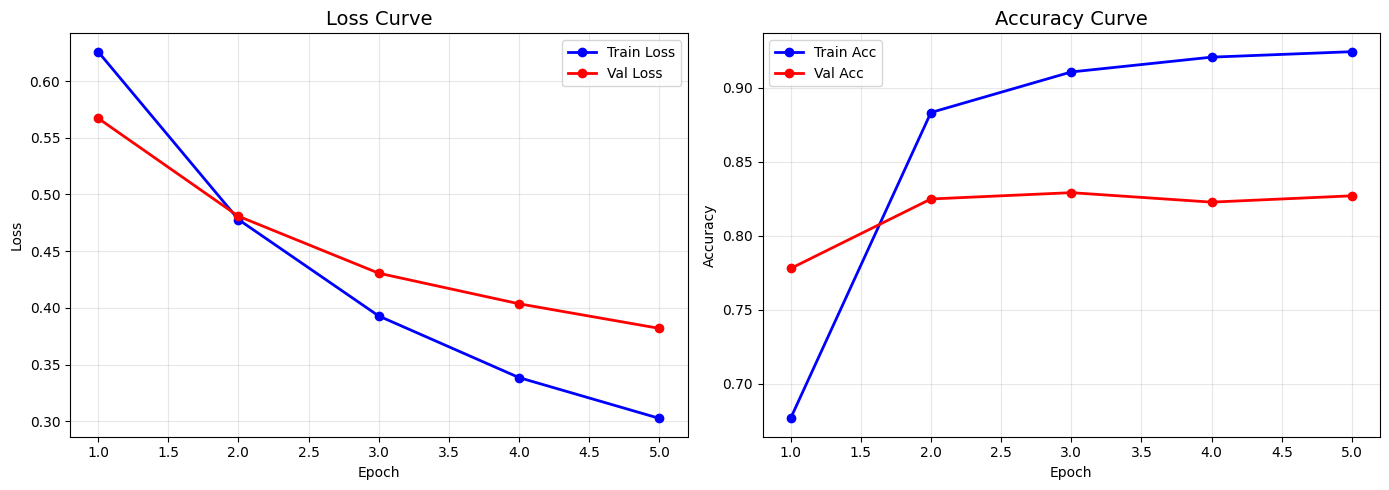

In [65]:
plot_loss_curves(
    val_loss=result["test_loss"],
    train_loss=result["train_loss"],
    val_acc=result["test_acc"],
    train_acc=result["train_acc"],
)

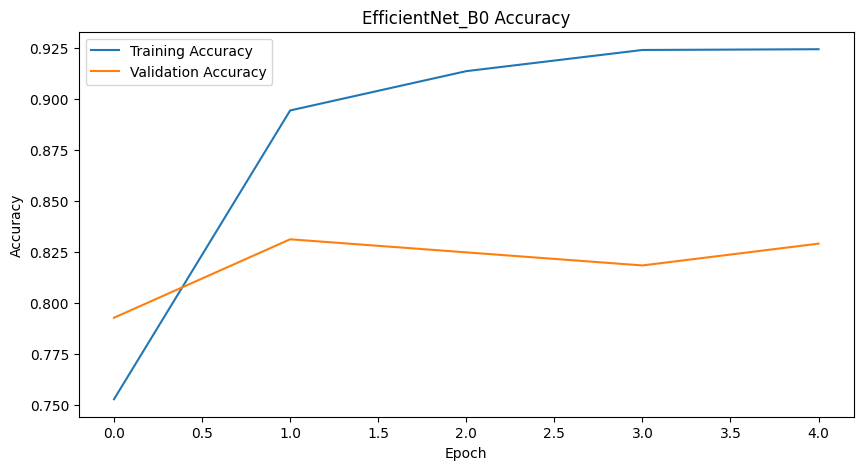

In [78]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    result["train_acc"],
    label="Training Accuracy"
)

plt.plot(
    result["test_acc"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("EfficientNet_B0 Accuracy") # Updated title to reflect EfficientNet
plt.legend()
plt.show()